# DDoS Detector Training

Training notebook placeholder.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = '/content/drive/MyDrive/spectra/ddo_mon_Jun_14.csv'
df1 = pd.read_csv(file_path)

display(df1.head())

,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,3/11/2014 18:21,Unknown_UDP,16076,0,0,178,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.5.122,udp_ip,5353,224.0.0.251,5353,6/13/2010 23:57,6/14/2010 0:11,Normal
1,3/11/2014 18:21,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.2.111,tcp_ip,4435,206.217.198.186,80,6/13/2010 23:58,6/14/2010 0:01,Normal
2,3/11/2014 18:21,DNS,171,642,4,2,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.4.119,udp_ip,4428,192.168.5.122,53,6/13/2010 23:58,6/13/2010 23:59,Normal
3,3/11/2014 18:21,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.4.119,tcp_ip,3639,219.94.203.105,80,6/13/2010 23:58,6/14/2010 0:00,Normal
4,3/11/2014 18:21,HTTPImageTransfer,186,128,2,2,NaN,NaN,NaN,NaN,...,"F,P,A",R,192.168.4.119,tcp_ip,3641,98.137.80.50,80,6/13/2010 23:58,6/13/2010 23:59,Normal


In [4]:
file_path = '/content/drive/MyDrive/spectra/ddo_tue_jun_15.csv'
df2 = pd.read_csv(file_path)

display(df2.head())

,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,3/11/2014 16:24,BitTorrent,391223,4114484,7322,5650,NaN,NaN,NaN,NaN,...,"F,P,A","F,P,A",192.168.2.107,tcp_ip,1989,80.246.149.72,6880,6/14/2010 21:54,6/15/2010 1:43,Normal
1,3/11/2014 16:24,Unknown_UDP,236345,5324121,4282,3378,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.2.107,udp_ip,58040,96.238.239.35,24457,6/14/2010 21:54,6/15/2010 0:52,Normal
2,3/11/2014 16:24,Unknown_UDP,410420,11797592,9416,5791,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.2.107,udp_ip,58040,220.126.251.32,27295,6/14/2010 21:55,6/15/2010 1:54,Normal
3,3/11/2014 16:24,BitTorrent,127588,2949293,2249,1853,NaN,NaN,NaN,NaN,...,"P,A","F,R,P,A",192.168.2.107,tcp_ip,2048,92.126.24.44,44817,6/14/2010 21:56,6/15/2010 0:53,Normal
4,3/11/2014 16:24,Unknown_UDP,389781,11382564,8837,5531,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.2.107,udp_ip,58040,67.173.154.16,53341,6/14/2010 21:57,6/15/2010 1:54,Normal


In [5]:
file_path = '/content/drive/MyDrive/spectra/ddo_sat_jun_12.csv'
df3 = pd.read_csv(file_path)

display(df3.head())

,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,3/11/2014 17:23,HTTPWeb,128,64,1,2,NaN,NaN,NaN,NaN,...,"F,A","F,A",192.168.1.104,tcp_ip,22441,216.246.64.49,80,6/12/2010 23:58,6/12/2010 23:58,Normal
1,3/11/2014 17:23,HTTPWeb,128,64,1,2,NaN,NaN,NaN,NaN,...,"F,A","F,A",192.168.1.104,tcp_ip,22445,216.246.64.66,80,6/12/2010 23:58,6/12/2010 23:58,Normal
2,3/11/2014 17:23,HTTPWeb,128,64,1,2,NaN,NaN,NaN,NaN,...,"F,A","F,A",192.168.1.104,tcp_ip,22444,216.246.64.66,80,6/12/2010 23:58,6/12/2010 23:58,Normal
3,3/11/2014 17:23,SSH,2938,49570,76,27,NaN,NaN,NaN,NaN,...,"S,R,P,A","S,P,A",192.168.3.115,tcp_ip,3248,192.168.5.122,22,6/12/2010 23:58,6/12/2010 23:58,Normal
4,3/11/2014 17:23,HTTPImageTransfer,644,2315,5,7,NaN,NaN,NaN,NaN,...,"S,P,A","S,P,A",192.168.2.110,tcp_ip,1867,142.166.14.77,80,6/12/2010 23:58,6/12/2010 23:58,Normal


In [6]:
file_path = '/content/drive/MyDrive/spectra/ddo_sun_jun_13.csv'
df4 = pd.read_csv(file_path)

display(df4.head())

,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,3/11/2014 17:35,Unknown_UDP,2633658,0,0,28971,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.5.122,udp_ip,5353,224.0.0.251,5353,6/12/2010 23:57,6/13/2010 9:24,Normal
1,3/11/2014 17:35,Unknown_UDP,2633658,0,0,28971,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.5.122,udp_ip,5353,224.0.0.251,5353,6/12/2010 23:57,6/13/2010 9:24,Normal
2,3/11/2014 17:35,HTTPWeb,64,128,2,1,NaN,NaN,NaN,NaN,...,"F,A",R,192.168.2.113,tcp_ip,4191,192.168.5.122,80,6/12/2010 23:57,6/12/2010 23:59,Normal
3,3/11/2014 17:35,HTTPWeb,64,128,2,1,NaN,NaN,NaN,NaN,...,"F,A",R,192.168.2.113,tcp_ip,4191,192.168.5.122,80,6/12/2010 23:57,6/12/2010 23:59,Normal
4,3/11/2014 17:35,HTTPWeb,128,64,1,2,NaN,NaN,NaN,NaN,...,"F,A","F,A",192.168.2.113,tcp_ip,4192,207.241.148.80,80,6/12/2010 23:57,6/12/2010 23:59,Normal


In [7]:
file_path = '/content/drive/MyDrive/spectra/ddo_wed_jun_16.csv'
df5 = pd.read_csv(file_path)

display(df5.head())

,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,3/11/2014 16:49,DNS,2073,15834,48,26,ISQBAAABAAAAAAAAA3d3dwdsZHVodHJwA25ldAAAAQABIS...,!$wwwlduhtrpnet!%wwwafcyhfcom!g-ecximages-amaz...,NaN,NaN,...,NaN,NaN,192.168.4.118,udp_ip,1266,192.168.5.122,53,6/15/2010 23:54,6/16/2010 0:06,Normal
1,3/11/2014 16:49,HTTPImageTransfer,64,0,0,1,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.4.118,tcp_ip,1592,198.173.85.138,80,6/15/2010 23:55,6/15/2010 23:59,Normal
2,3/11/2014 16:49,HTTPWeb,399,0,0,3,R0VUIC9pbWFnZXMvYXVmYXN0bG9va2Jhbm5lcjc2NS5KUE...,GET /images/aufastlookbanner765.JPG HTTP/1.1Ho...,NaN,NaN,...,"F,P,A",NaN,192.168.4.118,tcp_ip,1595,115.178.18.2,80,6/15/2010 23:56,6/16/2010 0:00,Normal
3,3/11/2014 16:49,HTTPWeb,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.2.109,tcp_ip,1683,95.154.240.242,80,6/15/2010 23:56,6/15/2010 23:59,Normal
4,3/11/2014 16:49,HTTPImageTransfer,3303,39226,48,35,NaN,NaN,NaN,NaN,...,"P,A","P,A",192.168.4.119,tcp_ip,4576,72.247.111.188,80,6/15/2010 23:56,6/16/2010 0:03,Normal


In [8]:
file_path = '/content/drive/MyDrive/spectra/ddo_thu_hun_17.csv'
df6 = pd.read_csv(file_path)

display(df6.head())

,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,5/20/2013 14:39,HTTPImageTransfer,0,64,1,0,NaN,NaN,NaN,NaN,...,NaN,A,192.168.1.105,tcp_ip,37221,203.73.24.75,80,6/16/2010 23:58,6/16/2010 23:59,Normal
1,5/20/2013 14:39,DNS,105,198,1,1,KfABAAABAAAAAAABC2ZvLWFueXljcy1kA2F5MQFiCHlhaG...,).....fo-anyycs-d.ay1.b.yahoodns.net..)..,KfCBgAABAAEAAgADC2ZvLWFueXljcy1kA2F5MQFiCHlhaG...,)........fo-anyycs-d.ay1.b.yahoodns.net..........,...,NaN,NaN,192.168.5.122,udp_ip,45465,198.164.30.2,53,6/16/2010 23:59,6/16/2010 23:59,Normal
2,5/20/2013 14:39,DNS,90,783,1,1,HjQBEAABAAAAAAABA25zNgNpdGEDZG9jA2dvdgAAHAABAA...,.4.....ns6.ita.doc.gov..)..,HjSBkAABAAAABAABA25zNgNpdGEDZG9jA2dvdgAAHAABwB...,.4......ns6.ita.doc.gov........'.ns1..postmast...,...,NaN,NaN,192.168.5.122,udp_ip,49218,198.164.30.2,53,6/16/2010 23:59,6/16/2010 23:59,Normal
3,5/20/2013 14:39,DNS,90,776,1,1,FQoBEAABAAAAAAABA25zNQNpdGEDZG9jA2dvdgAAHAABAA...,......ns5.ita.doc.gov..)..,FQqBkAABAAAABAABA25zNQNpdGEDZG9jA2dvdgAAHAABwB...,.......ns5.ita.doc.gov........'.ns1..postmaste...,...,NaN,NaN,192.168.5.122,udp_ip,53705,198.164.30.2,53,6/16/2010 23:59,6/16/2010 23:59,Normal
4,5/20/2013 14:39,HTTPImageTransfer,128,1071,3,2,NaN,NaN,NaN,NaN,...,"F,A","F,P,A",192.168.1.104,tcp_ip,27253,64.38.193.26,80,6/16/2010 23:58,6/16/2010 23:59,Normal


In [14]:
df1.info()
df2.info()
df3.info()
df4.info()
df5.info()
df6.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171380 entries, 0 to 171379
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   generated                       171380 non-null  object 
 1   appName                         171380 non-null  object 
 2   totalSourceBytes                171380 non-null  int64  
 3   totalDestinationBytes           171380 non-null  int64  
 4   totalDestinationPackets         171380 non-null  int64  
 5   totalSourcePackets              171380 non-null  int64  
 6   sourcePayloadAsBase64           84579 non-null   object 
 7   sourcePayloadAsUTF              0 non-null       float64
 8   destinationPayloadAsBase64      74634 non-null   object 
 9   destinationPayloadAsUTF         74616 non-null   object 
 10  direction                       171380 non-null  object 
 11  sourceTCPFlagsDescription       122074 non-null  object 
 12  destinationTCPFl

In [15]:
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071657 entries, 0 to 2071656
Data columns (total 21 columns):
 #   Column                          Dtype 
---  ------                          ----- 
 0   generated                       object
 1   appName                         object
 2   totalSourceBytes                int64 
 3   totalDestinationBytes           int64 
 4   totalDestinationPackets         int64 
 5   totalSourcePackets              int64 
 6   sourcePayloadAsBase64           object
 7   sourcePayloadAsUTF              object
 8   destinationPayloadAsBase64      object
 9   destinationPayloadAsUTF         object
 10  direction                       object
 11  sourceTCPFlagsDescription       object
 12  destinationTCPFlagsDescription  object
 13  source                          object
 14  protocolName                    object
 15  sourcePort                      int64 
 16  destination                     object
 17  destinationPort                 int64 
 18  st

,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,3/11/2014 18:21,Unknown_UDP,16076,0,0,178,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.5.122,udp_ip,5353,224.0.0.251,5353,6/13/2010 23:57,6/14/2010 0:11,Normal
1,3/11/2014 18:21,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.2.111,tcp_ip,4435,206.217.198.186,80,6/13/2010 23:58,6/14/2010 0:01,Normal
2,3/11/2014 18:21,DNS,171,642,4,2,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.4.119,udp_ip,4428,192.168.5.122,53,6/13/2010 23:58,6/13/2010 23:59,Normal
3,3/11/2014 18:21,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.4.119,tcp_ip,3639,219.94.203.105,80,6/13/2010 23:58,6/14/2010 0:00,Normal
4,3/11/2014 18:21,HTTPImageTransfer,186,128,2,2,NaN,NaN,NaN,NaN,...,"F,P,A",R,192.168.4.119,tcp_ip,3641,98.137.80.50,80,6/13/2010 23:58,6/13/2010 23:59,Normal


In [16]:
df['Label'].value_counts()

,count
Label,
Normal,2002747
Attack,68910


In [17]:
drop_cols = [
    'sourcePayloadAsBase64', 'sourcePayloadAsUTF',
    'destinationPayloadAsBase64', 'destinationPayloadAsUTF',
    'generated', 'appName'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [18]:
df['startDateTime'] = pd.to_datetime(df['startDateTime'])
df['stopDateTime'] = pd.to_datetime(df['stopDateTime'])
df = df.sort_values('startDateTime').reset_index(drop=True)

In [20]:
df['duration'] = (df['stopDateTime'] - df['startDateTime']).dt.total_seconds().clip(lower=0.001)

df['packets_per_second'] = (df['totalSourcePackets'] + df['totalDestinationPackets']) / df['duration']
df['bytes_per_second'] = (df['totalSourceBytes'] + df['totalDestinationBytes']) / df['duration']

# Traffic asymmetry features
df['byte_asymmetry'] = np.abs(df['totalSourceBytes'] - df['totalDestinationBytes']) / (df['totalSourceBytes'] + df['totalDestinationBytes'] + 1)
df['packet_asymmetry'] = np.abs(df['totalSourcePackets'] - df['totalDestinationPackets']) / (df['totalSourcePackets'] + df['totalDestinationPackets'] + 1)
df['bidirectional_ratio'] = df['totalDestinationBytes'] / (df['totalSourceBytes'] + df['totalDestinationBytes'] + 1)

# TCP flag features
df['flags'] = df['sourceTCPFlagsDescription'].fillna('')
df['syn_ratio'] = df['flags'].str.contains('S').astype(int)
df['rst_ratio'] = df['flags'].str.contains('R').astype(int)
df['syn_without_data'] = ((df['syn_ratio'] == 1) & (df['totalSourceBytes'] < 100)).astype(int)

df = df.set_index('startDateTime')

# New Section

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2071657 entries, 2010-06-11 20:10:00 to 2010-06-17 23:58:00
Data columns (total 24 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   totalSourceBytes                int64         
 1   totalDestinationBytes           int64         
 2   totalDestinationPackets         int64         
 3   totalSourcePackets              int64         
 4   direction                       object        
 5   sourceTCPFlagsDescription       object        
 6   destinationTCPFlagsDescription  object        
 7   source                          object        
 8   protocolName                    object        
 9   sourcePort                      int64         
 10  destination                     object        
 11  destinationPort                 int64         
 12  stopDateTime                    datetime64[ns]
 13  Label                           object        
 14  duration         

In [23]:
df.describe()

,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePort,destinationPort,stopDateTime,duration,packets_per_second,bytes_per_second,byte_asymmetry,packet_asymmetry,bidirectional_ratio,syn_ratio,rst_ratio,syn_without_data
count,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06,2071657,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06,2.071657e+06
mean,2.460947e+03,3.448911e+04,3.030068e+01,1.984019e+01,1.413759e+04,1.882091e+03,2010-06-15 14:18:37.406172928,4.898777e+01,2.521548e+04,1.633100e+07,6.159376e-01,1.540684e-01,7.049374e-01,6.964782e-01,2.139833e-02,1.152990e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2010-06-11 23:59:00,1.000000e-03,5.973716e-05,9.318996e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.560000e+02,4.190000e+02,2.000000e+00,3.000000e+00,2.302000e+03,8.000000e+01,2010-06-14 11:13:00,1.000000e-03,2.000000e+03,2.490000e+05,3.542435e-01,0.000000e+00,6.233010e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.420000e+02,1.177000e+03,5.000000e+00,6.000000e+00,3.744000e+03,8.000000e+01,2010-06-15 16:56:00,1.000000e-03,1.000000e+04,1.165000e+06,6.600840e-01,9.615385e-02,7.746289e-01,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.450000e+02,7.338000e+03,1.100000e+01,1.000000e+01,1.699300e+04,8.000000e+01,2010-06-16 18:26:00,1.000000e-03,1.400000e+04,4.292000e+06,9.017061e-01,2.500000e-01,9.141816e-01,1.000000e+00,0.000000e+00,0.000000e+00
max,7.632776e+08,1.254005e+09,8.722240e+05,5.147940e+05,6.553500e+04,6.553500e+04,2010-06-17 23:58:00,4.914000e+04,2.802800e+07,2.051278e+10,9.999996e-01,9.999655e-01,9.999982e-01,1.000000e+00,1.000000e+00,1.000000e+00
std,7.517785e+05,1.187177e+06,9.834982e+02,6.679018e+02,2.014297e+04,8.623280e+03,NaN,6.197692e+02,1.000977e+05,8.122032e+07,2.937572e-01,2.021172e-01,2.730417e-01,4.597787e-01,1.447082e-01,1.067566e-01


In [24]:
def calculate_entropy(ip_series):
    counts = ip_series.value_counts(normalize=True)
    return -(counts * np.log2(counts)).sum()

# 5-second window features (existing)
df['time_bucket_5s'] = df.index.floor('5s')
windowed_5s = df.groupby(['destination', 'time_bucket_5s']).agg(
    unique_source_ips_5s=('source', 'nunique'),
    source_ip_entropy_5s=('source', calculate_entropy)
).reset_index()

df = df.reset_index().merge(windowed_5s, on=['destination', 'time_bucket_5s'], how='left')

# 30-second window features
df['time_bucket_30s'] = pd.to_datetime(df['startDateTime']).dt.floor('30s')
windowed_30s = df.groupby(['destination', 'time_bucket_30s']).agg(
    flows_30s=('source', 'count'),
    unique_sources_30s=('source', 'nunique'),
    protocol_diversity_30s=('protocolName', 'nunique'),
    byte_rate_mean_30s=('bytes_per_second', 'mean')
).reset_index()

df = df.merge(windowed_30s, on=['destination', 'time_bucket_30s'], how='left')

# 60-second window features
df['time_bucket_60s'] = pd.to_datetime(df['startDateTime']).dt.floor('60s')
windowed_60s = df.groupby(['destination', 'time_bucket_60s']).agg(
    flows_60s=('source', 'count'),
    unique_sources_60s=('source', 'nunique'),
    protocol_diversity_60s=('protocolName', 'nunique'),
    byte_rate_mean_60s=('bytes_per_second', 'mean')
).reset_index()

df = df.merge(windowed_60s, on=['destination', 'time_bucket_60s'], how='left')

df = df.drop(columns=['time_bucket_5s', 'time_bucket_30s', 'time_bucket_60s'])
df = df.set_index('startDateTime')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2071657 entries, 2010-06-11 20:10:00 to 2010-06-17 23:58:00
Data columns (total 34 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   totalSourceBytes                int64         
 1   totalDestinationBytes           int64         
 2   totalDestinationPackets         int64         
 3   totalSourcePackets              int64         
 4   direction                       object        
 5   sourceTCPFlagsDescription       object        
 6   destinationTCPFlagsDescription  object        
 7   source                          object        
 8   protocolName                    object        
 9   sourcePort                      int64         
 10  destination                     object        
 11  destinationPort                 int64         
 12  stopDateTime                    datetime64[ns]
 13  Label                           object        
 14  duration         

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# 1. Extract the date directly from the datetime index
df['date_only'] = df.index.date

# 2. One-hot encode the categorical features BEFORE splitting
df = pd.get_dummies(df, columns=['protocolName', 'direction'], drop_first=True)

X_train_chunks, X_test_chunks = [], []
y_train_chunks, y_test_chunks = [], []

# 3. Group by the exact day (June 14 vs June 15)
for date, daily_data in df.groupby('date_only'):

    # Drop all raw metadata, original counters, identifiers, and the target Label
    # 'startDateTime' is now the index, so it won't be in columns to drop
    X_daily = daily_data.drop(columns=[
        'stopDateTime', 'source', 'destination',
        'sourcePort', 'destinationPort', 'sourceTCPFlagsDescription',
        'destinationTCPFlagsDescription', 'flags', 'duration',
        'totalSourceBytes', 'totalDestinationBytes',
        'totalDestinationPackets', 'totalSourcePackets',
        'Label', 'date_only'
    ], errors='ignore')

    # Convert string labels to binary
    y_daily = daily_data['Label'].apply(lambda x: 0 if x == 'Normal' else 1)

    # Chronological split for THIS day (no shuffling)
    X_tr, X_te, y_tr, y_te = train_test_split(X_daily, y_daily, test_size=0.2, shuffle=False)

    X_train_chunks.append(X_tr)
    X_test_chunks.append(X_te)
    y_train_chunks.append(y_tr)
    y_test_chunks.append(y_te)

# 4. Combine the chunks back into final Train and Test sets
X_train = pd.concat(X_train_chunks)
X_test = pd.concat(X_test_chunks)
y_train = pd.concat(y_train_chunks)
y_test = pd.concat(y_test_chunks)

In [29]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1657323 entries, 2010-06-11 20:10:00 to 2010-06-17 14:07:00
Data columns (total 26 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   packets_per_second      1657323 non-null  float64
 1   bytes_per_second        1657323 non-null  float64
 2   byte_asymmetry          1657323 non-null  float64
 3   packet_asymmetry        1657323 non-null  float64
 4   bidirectional_ratio     1657323 non-null  float64
 5   syn_ratio               1657323 non-null  int64  
 6   rst_ratio               1657323 non-null  int64  
 7   syn_without_data        1657323 non-null  int64  
 8   unique_source_ips_5s    1657323 non-null  int64  
 9   source_ip_entropy_5s    1657323 non-null  float64
 10  flows_30s               1657323 non-null  int64  
 11  unique_sources_30s      1657323 non-null  int64  
 12  protocol_diversity_30s  1657323 non-null  int64  
 13  byte_rate_mean_30s      

In [37]:
import pandas as pd

# Combine X_train and y_train temporarily to undersample safely
train_df = X_train.copy()
train_df['Label'] = y_train

# Separate normal and attack rows in the training set
normal_df = train_df[train_df['Label'] == 0]
attack_df = train_df[train_df['Label'] == 1]

# Aggressive 1:1 undersampling for better attack detection
normal_downsampled = normal_df.sample(n=len(attack_df) * 1)

# Recombine and shuffle just the training partition
balanced_train = pd.concat([normal_downsampled, attack_df]).sample(frac=1)

# Separate back into X_train and y_train
X_train = balanced_train.drop(columns=['Label'])
y_train = balanced_train['Label']

print(f"New training set size: {X_train.shape}")
print(f"Class distribution:\n{y_train.value_counts()}")

New training set size: (99828, 26)
Class distribution:
Label
1    49914
0    49914
Name: count, dtype: int64


In [38]:
X_train.shape

(99828, 26)

In [39]:
y_train.value_counts()

,count
Label,
1,49914
0,49914


In [40]:
X_train.describe()

,packets_per_second,bytes_per_second,byte_asymmetry,packet_asymmetry,bidirectional_ratio,syn_ratio,rst_ratio,syn_without_data,unique_source_ips_5s,source_ip_entropy_5s,flows_30s,unique_sources_30s,protocol_diversity_30s,byte_rate_mean_30s,flows_60s,unique_sources_60s,protocol_diversity_60s,byte_rate_mean_60s
count,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000,99828.000000
mean,0.379131,0.352615,-0.388977,0.060856,-0.292803,0.836749,0.014395,0.113615,0.393403,0.406124,0.378317,0.393403,-0.483712,0.325339,0.378317,0.393403,-0.483712,0.325339
std,0.596552,0.550391,0.625241,0.533136,0.618172,0.369596,0.119112,0.317345,0.506163,0.478210,0.713689,0.506163,0.506526,0.493782,0.713689,0.506163,0.506526,0.493782
min,-0.054545,-0.012655,-1.481511,-0.489435,-2.038558,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.278146,0.000000,-1.000000,-0.046197,-0.278146,0.000000,-1.000000,-0.046197
25%,-0.045455,-0.011221,-0.899181,-0.489435,-0.808100,1.000000,0.000000,0.000000,0.000000,-0.000000,-0.258278,0.000000,-1.000000,-0.043830,-0.258278,0.000000,-1.000000,-0.043830
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.954545,0.988779,0.100819,0.510565,0.191900,1.000000,0.000000,0.000000,1.000000,1.000000,0.741722,1.000000,0.000000,0.956170,0.741722,1.000000,0.000000,0.956170
max,31.450000,40.546105,0.278484,2.144530,0.310018,1.000000,1.000000,1.000000,6.916667,2.270383,1.927152,6.916667,1.000000,21.048780,1.927152,6.916667,1.000000,21.048780


In [41]:
from sklearn.preprocessing import RobustScaler

# Define continuous numerical columns (expanded with new features)
continuous_cols = [
    'packets_per_second', 'bytes_per_second', 'unique_source_ips_5s', 'source_ip_entropy_5s',
    'byte_asymmetry', 'packet_asymmetry', 'bidirectional_ratio',
    'flows_30s', 'unique_sources_30s', 'protocol_diversity_30s', 'byte_rate_mean_30s',
    'flows_60s', 'unique_sources_60s', 'protocol_diversity_60s', 'byte_rate_mean_60s'
]

# Filter to only columns that exist
continuous_cols = [c for c in continuous_cols if c in X_train.columns]

# Initialize and apply RobustScaler
scaler = RobustScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(f"Scaled {len(continuous_cols)} continuous features")
print(X_train[continuous_cols].describe())

Scaled 15 continuous features
       packets_per_second  bytes_per_second  unique_source_ips_5s  \
count        99828.000000      99828.000000          99828.000000   
mean             0.379131          0.352615              0.393403   
std              0.596552          0.550391              0.506163   
min             -0.054545         -0.012655              0.000000   
25%             -0.045455         -0.011221              0.000000   
50%              0.000000          0.000000              0.000000   
75%              0.954545          0.988779              1.000000   
max             31.450000         40.546105              6.916667   

       source_ip_entropy_5s  byte_asymmetry  packet_asymmetry  \
count          99828.000000    99828.000000      99828.000000   
mean               0.406124       -0.388977          0.060856   
std                0.478210        0.625241          0.533136   
min               -0.000000       -1.481511         -0.489435   
25%               -0.00

In [42]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, f1_score
import matplotlib.pyplot as plt

# Safety net: Sanitize any lingering Infinities
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# Create validation split from training data (80/20 chronological)
split_idx = int(len(X_train) * 0.8)
X_train_cv = X_train.iloc[:split_idx]
X_val_cv = X_train.iloc[split_idx:]
y_train_cv = y_train.iloc[:split_idx]
y_val_cv = y_train.iloc[split_idx:]

# Calculate dynamic imbalance ratio
imbalance_ratio = (y_train_cv == 0).sum() / (y_train_cv == 1).sum()
print(f"Dynamic imbalance ratio: {imbalance_ratio:.2f}")

# Initialize model with dynamic weights
model = XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    tree_method='hist',
    device='cpu',  # Use CPU; GPU device mismatch fixed
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=10,
    n_estimators=500
)

# Train with early stopping on validation set
print("Training model with early stopping...")
model.fit(
    X_train_cv, y_train_cv,
    eval_set=[(X_val_cv, y_val_cv)],
    verbose=50
)

# Generate predictions and probabilities on test set
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve for threshold tuning
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Find Youden index optimal threshold
youden_idx = np.argmax(tpr - fpr)
youden_threshold = thresholds[youden_idx]

# Calculate precision-recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probs)

# Find F1-optimal threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
f1_idx = np.argmax(f1_scores)
f1_threshold = pr_thresholds[f1_idx] if f1_idx < len(pr_thresholds) else 0.5

print(f"\nROC AUC: {roc_auc:.4f}")
print(f"Youden optimal threshold: {youden_threshold:.4f}")
print(f"F1-optimal threshold: {f1_threshold:.4f}")

# Evaluate at default threshold (0.5)
print("\n=== Default Threshold (0.5) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Evaluate at Youden threshold
y_pred_youden = (y_probs >= youden_threshold).astype(int)
print(f"\n=== Youden Threshold ({youden_threshold:.4f}) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_youden))
print("\nClassification Report:\n", classification_report(y_test, y_pred_youden))

# Evaluate at F1 threshold
y_pred_f1 = (y_probs >= f1_threshold).astype(int)
print(f"\n=== F1-Optimal Threshold ({f1_threshold:.4f}) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_f1))
print("\nClassification Report:\n", classification_report(y_test, y_pred_f1))

Dynamic imbalance ratio: 1.00
Training model with early stopping...
[0]	validation_0-logloss:0.44348
[50]	validation_0-logloss:0.01318
[100]	validation_0-logloss:0.01220
[106]	validation_0-logloss:0.01224

ROC AUC: 0.9836
Youden optimal threshold: 0.0073
F1-optimal threshold: 0.3575

=== Default Threshold (0.5) ===
Confusion Matrix:
 [[394006   1332]
 [  4607  14389]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    395338
           1       0.92      0.76      0.83     18996

    accuracy                           0.99    414334
   macro avg       0.95      0.88      0.91    414334
weighted avg       0.99      0.99      0.99    414334


=== Youden Threshold (0.0073) ===
Confusion Matrix:
 [[378063  17275]
 [  1199  17797]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98    395338
           1       0.51      0.94      0.66     18996


Saved model analysis plot to ddos_model_analysis.png

=== Top 15 Most Important Features ===
flows_30s                           0.4183
protocolName_tcp_ip                 0.2570
direction_L2R                       0.1276
syn_without_data                    0.0550
direction_R2L                       0.0501
protocol_diversity_30s              0.0190
bidirectional_ratio                 0.0168
protocolName_udp_ip                 0.0145
byte_asymmetry                      0.0070
unique_source_ips_5s                0.0067
byte_rate_mean_30s                  0.0062
syn_ratio                           0.0057
packets_per_second                  0.0039
packet_asymmetry                    0.0036
rst_ratio                           0.0032


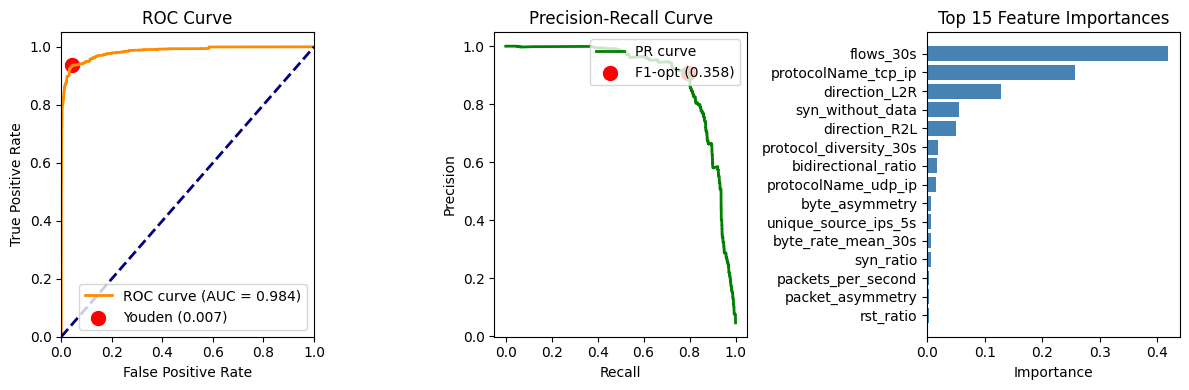

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Plot ROC curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[youden_idx], tpr[youden_idx], color='red', s=100, label=f'Youden ({youden_threshold:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# Plot Precision-Recall curve
plt.subplot(1, 3, 2)
plt.plot(recall, precision, color='green', lw=2, label='PR curve')
plt.scatter(recall[f1_idx] if f1_idx < len(recall) else 0,
           precision[f1_idx] if f1_idx < len(precision) else 0,
           color='red', s=100, label=f'F1-opt ({f1_threshold:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")

# Plot feature importance
feature_importance = model.feature_importances_
feature_names = X_train.columns
sorted_idx = np.argsort(feature_importance)[-15:]

plt.subplot(1, 3, 3)
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], color='steelblue')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')

plt.tight_layout()
plt.savefig('ddos_model_analysis.png', dpi=100, bbox_inches='tight')
print("Saved model analysis plot to ddos_model_analysis.png")

# Print top features
print("\n=== Top 15 Most Important Features ===")
for idx in sorted_idx[::-1]:
    print(f"{feature_names[idx]:<35} {feature_importance[idx]:.4f}")

In [44]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Safety net: Sanitize any lingering Infinities
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# Use a moderated scale_pos_weight (e.g., 5.0 instead of the full extreme ratio)
# to prevent probability compression and massive false-positive spikes.
model = XGBClassifier(
    scale_pos_weight=5.0,
    tree_method='hist',
    device='cuda',
    random_state=42,
    eval_metric='logloss'
)

# Train the model
print("Training model with production-tuned weights...")
model.fit(X_train, y_train)

# Generate raw probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Apply a realistic, operational threshold (0.3) suitable for a streaming pipeline
production_threshold = 0.1
y_pred_prod = (y_probs >= production_threshold).astype(int)

# Evaluate performance
print("\nProduction-Tuned Confusion Matrix:\n", confusion_matrix(y_test, y_pred_prod))
print("\nProduction-Tuned Classification Report:\n", classification_report(y_test, y_pred_prod))

Training model with production-tuned weights...


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [08:37:43] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Production-Tuned Confusion Matrix:
 [[390883   4455]
 [  3217  15779]]

Production-Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    395338
           1       0.78      0.83      0.80     18996

    accuracy                           0.98    414334
   macro avg       0.89      0.91      0.90    414334
weighted avg       0.98      0.98      0.98    414334



In [45]:
import joblib

# Save the trained XGBoost model with the F1-optimal threshold
model_metadata = {
    'threshold_default': 0.5,
    'threshold_youden': float(youden_threshold),
    'threshold_f1_optimal': float(f1_threshold),
    'roc_auc': float(roc_auc),
    'imbalance_ratio': float(imbalance_ratio),
    'feature_names': list(X_train.columns),
    'training_config': {
        'scale_pos_weight': imbalance_ratio,
        'tree_method': 'hist',
        'random_state': 42,
        'early_stopping_rounds': 10
    }
}

# 1. Save the trained XGBoost model
joblib.dump(model, 'xgboost_ddos_model.pkl')

# 2. Save the fitted RobustScaler for live inference
joblib.dump(scaler, 'robust_scaler.pkl')

# 3. Save metadata for inference pipeline
joblib.dump(model_metadata, 'model_metadata.pkl')

print("✓ Model saved to xgboost_ddos_model.pkl")
print("✓ Scaler saved to robust_scaler.pkl")
print("✓ Metadata saved to model_metadata.pkl")
print(f"\nRecommended Production Threshold: {f1_threshold:.4f} (F1-optimal)")
print(f"Alternative High-Recall Threshold: {youden_threshold:.4f} (Youden)")
print(f"Model ROC AUC: {roc_auc:.4f}")

✓ Model saved to xgboost_ddos_model.pkl
✓ Scaler saved to robust_scaler.pkl
✓ Metadata saved to model_metadata.pkl

Recommended Production Threshold: 0.3575 (F1-optimal)
Alternative High-Recall Threshold: 0.0073 (Youden)
Model ROC AUC: 0.9836
